<a href="https://colab.research.google.com/github/KelvynBladen/Colab/blob/main/notebooks/full_bikes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
# pip install pandas
# pip install polars

In [59]:
import pandas as pd
import polars as pl
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [60]:
#%%timeit
bikes = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bikes.csv')

In [61]:
#%%timeit
bikes_pol = pl.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bikes.csv')

In [62]:
print(bikes.info())
print(bikes.describe())
bikes.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112475 entries, 0 to 112474
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   dteday        112475 non-null  object 
 1   hr            112475 non-null  float64
 2   casual        112475 non-null  int64  
 3   registered    112475 non-null  int64  
 4   temp_c        112475 non-null  float64
 5   feels_like_c  112475 non-null  float64
 6   hum           112475 non-null  float64
 7   windspeed     112475 non-null  float64
 8   weathersit    112475 non-null  int64  
 9   season        112475 non-null  int64  
 10  holiday       112475 non-null  int64  
 11  workingday    112475 non-null  int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 10.3+ MB
None
                  hr         casual     registered         temp_c  \
count  112475.000000  112475.000000  112475.000000  112475.000000   
mean       11.501098      90.434612     249.193625      15.376487  

,dteday,hr,casual,registered,temp_c,feels_like_c,hum,windspeed,weathersit,season,holiday,workingday
0,1/1/2011,0.0,3,13,3.0,3.0,0.7957,0.8,1,1,0,0
1,1/1/2011,1.0,8,30,1.7,1.7,0.8272,0.8,1,1,0,0
2,1/1/2011,2.0,5,26,1.9,1.9,0.8157,1.1,1,1,0,0
3,1/1/2011,3.0,3,9,2.5,2.5,0.7831,0.8,1,1,0,0
4,1/1/2011,4.0,0,1,2.0,2.0,0.8075,1.1,1,1,0,0


In [63]:
print(bikes_pol.describe())
bikes_pol

shape: (9, 13)
┌────────────┬──────────┬───────────┬────────────┬───┬───────────┬──────────┬──────────┬───────────┐
│ statistic  ┆ dteday   ┆ hr        ┆ casual     ┆ … ┆ weathersi ┆ season   ┆ holiday  ┆ workingda │
│ ---        ┆ ---      ┆ ---       ┆ ---        ┆   ┆ t         ┆ ---      ┆ ---      ┆ y         │
│ str        ┆ str      ┆ f64       ┆ f64        ┆   ┆ ---       ┆ f64      ┆ f64      ┆ ---       │
│            ┆          ┆           ┆            ┆   ┆ f64       ┆          ┆          ┆ f64       │
╞════════════╪══════════╪═══════════╪════════════╪═══╪═══════════╪══════════╪══════════╪═══════════╡
│ count      ┆ 112475   ┆ 112475.0  ┆ 112475.0   ┆ … ┆ 112475.0  ┆ 112475.0 ┆ 112475.0 ┆ 112475.0  │
│ null_count ┆ 0        ┆ 0.0       ┆ 0.0        ┆ … ┆ 0.0       ┆ 0.0      ┆ 0.0      ┆ 0.0       │
│ mean       ┆ null     ┆ 11.501098 ┆ 90.434612  ┆ … ┆ 1.405441  ┆ 2.495799 ┆ 0.0303   ┆ 0.684312  │
│ std        ┆ null     ┆ 6.921864  ┆ 128.655621 ┆ … ┆ 0.68345   ┆ 1.101152 

dteday,hr,casual,registered,temp_c,feels_like_c,hum,windspeed,weathersit,season,holiday,workingday
str,f64,i64,i64,f64,f64,f64,f64,i64,i64,i64,i64
"""1/1/2011""",0.0,3,13,3.0,3.0,0.7957,0.8,1,1,0,0
"""1/1/2011""",1.0,8,30,1.7,1.7,0.8272,0.8,1,1,0,0
"""1/1/2011""",2.0,5,26,1.9,1.9,0.8157,1.1,1,1,0,0
"""1/1/2011""",3.0,3,9,2.5,2.5,0.7831,0.8,1,1,0,0
"""1/1/2011""",4.0,0,1,2.0,2.0,0.8075,1.1,1,1,0,0
…,…,…,…,…,…,…,…,…,…,…,…
"""10/31/2023""",19.0,241,594,10.2,10.2,0.4516,8.4,2,4,0,1
"""10/31/2023""",20.0,171,450,8.9,7.5,0.5268,9.3,1,4,0,1
"""10/31/2023""",21.0,176,402,7.7,6.4,0.5756,7.8,1,4,0,1


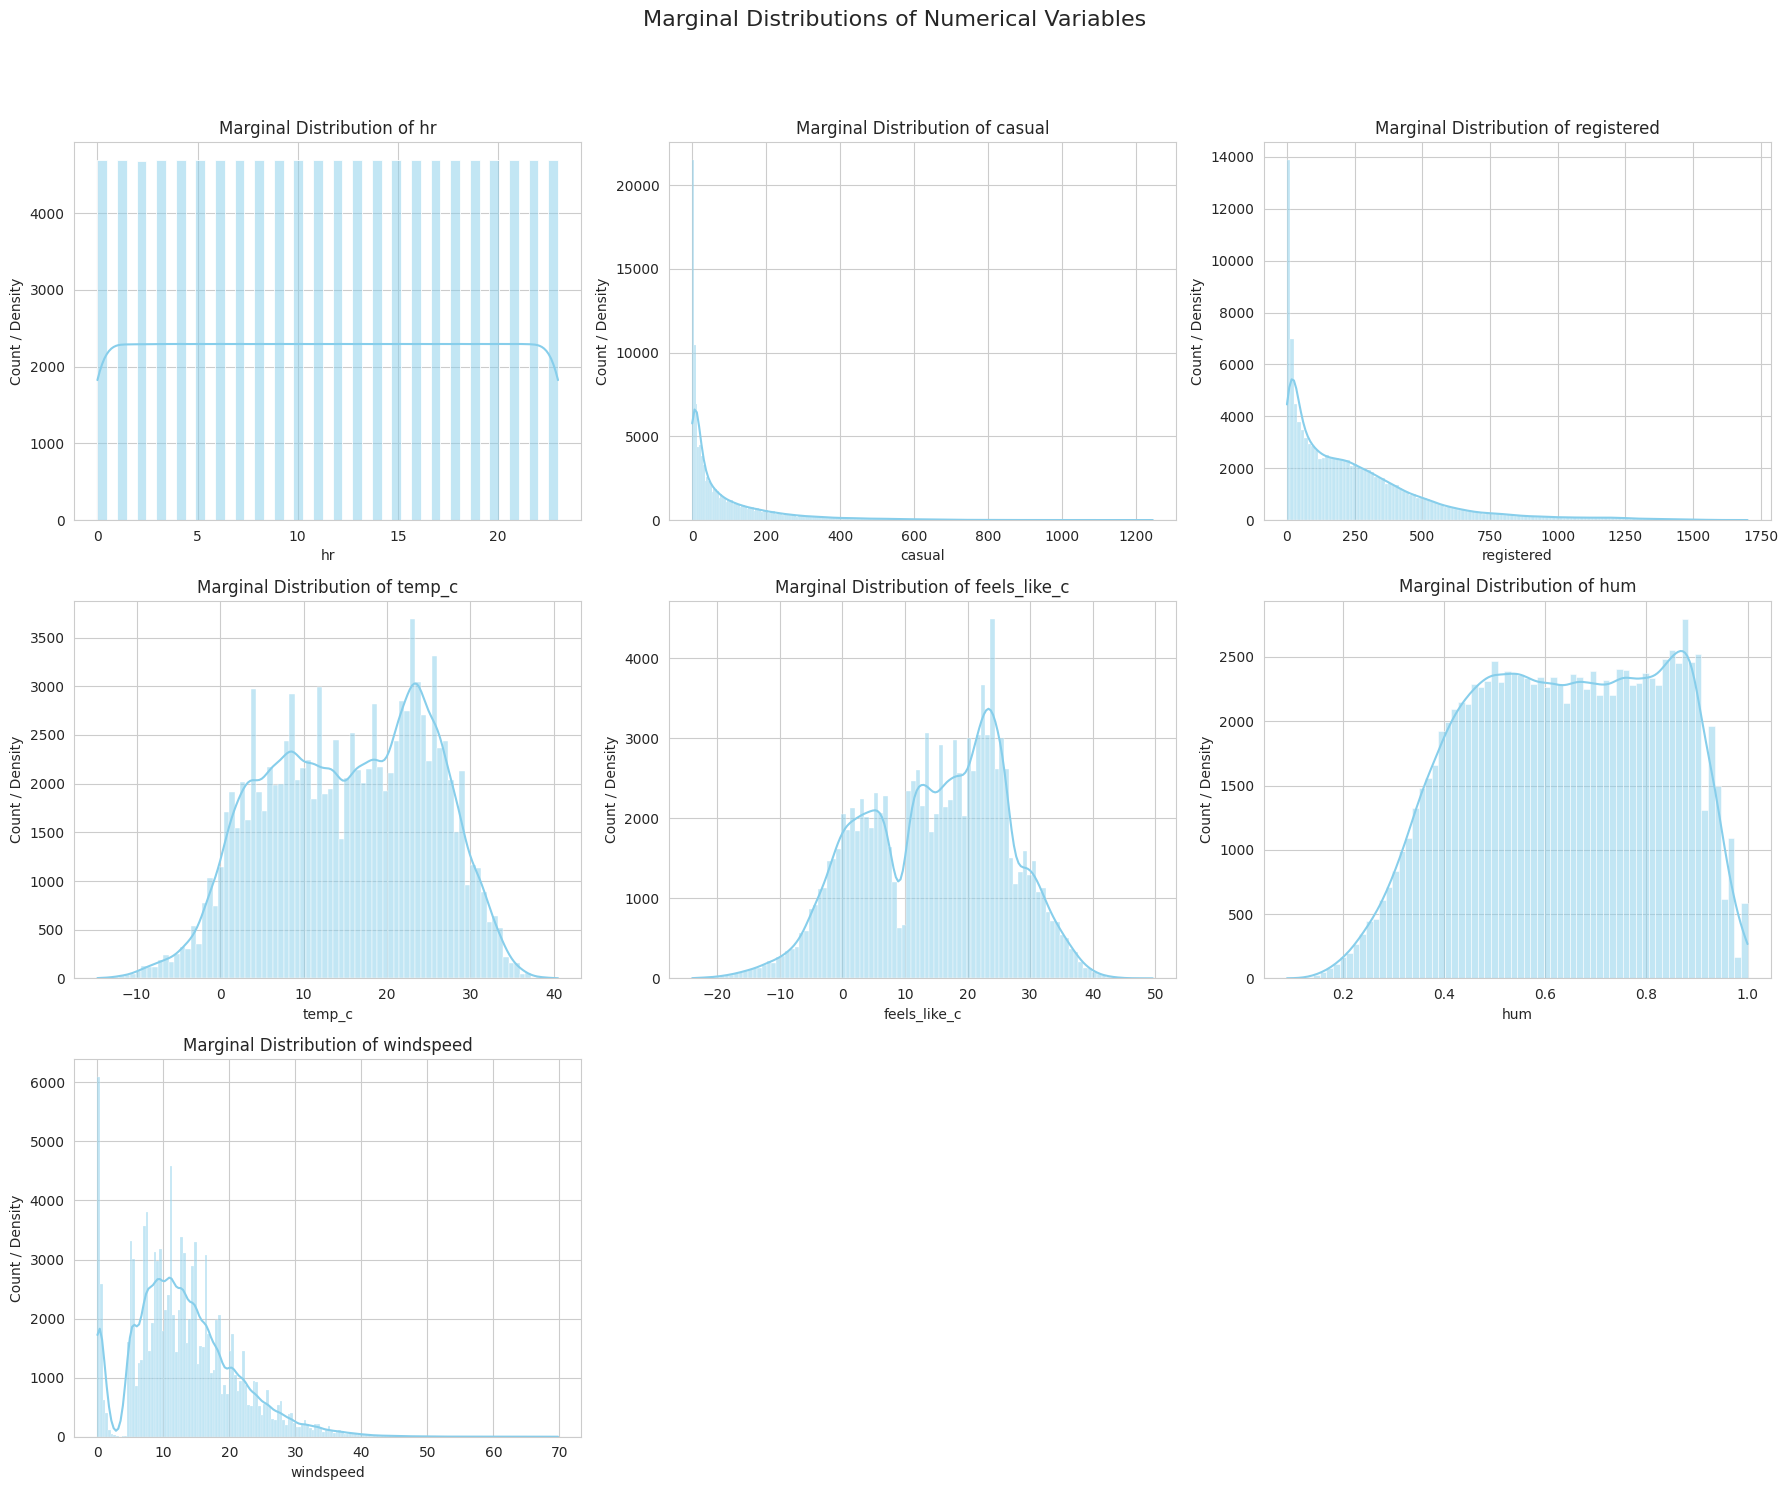

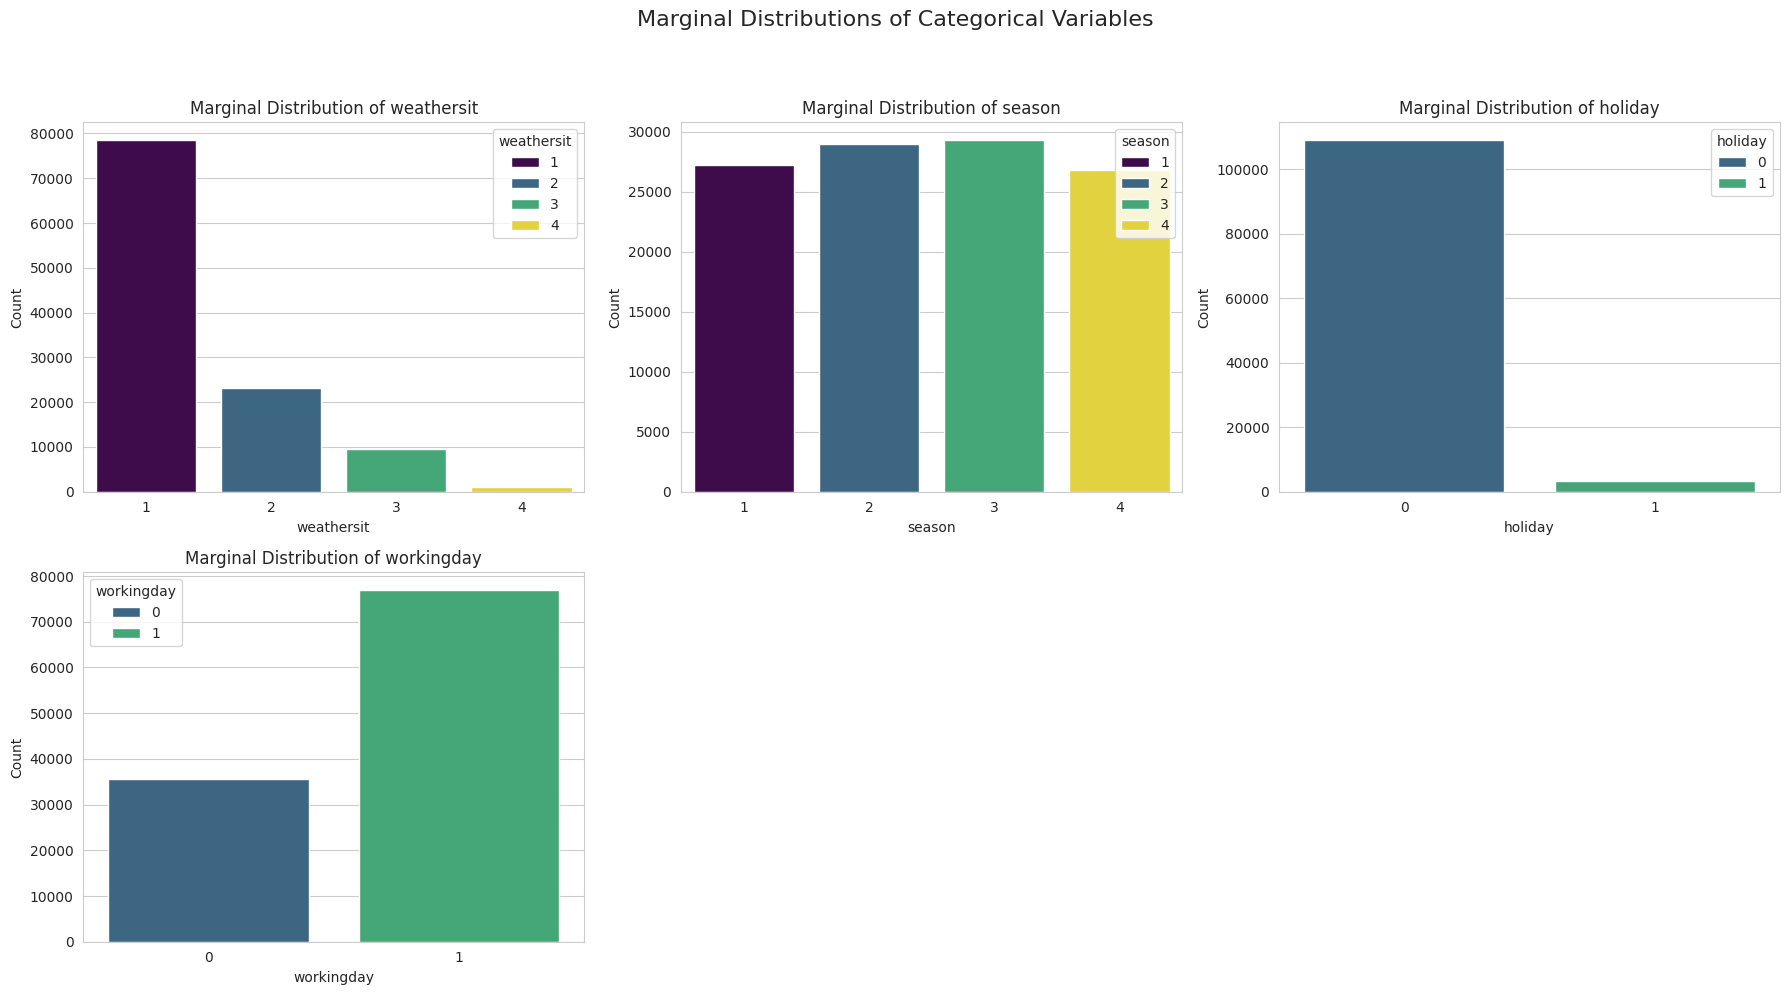

In [67]:
# Identify numerical and categorical columns (excluding 'dteday' as it's an object type for dates)
numerical_cols = [
    'hr', 'casual', 'registered', 'temp_c', 'feels_like_c', 'hum', 'windspeed'
]
categorical_cols = ['weathersit', 'season', 'holiday', 'workingday']

sns.set_style("whitegrid")

# --- Plotting Marginal Distributions for Numerical Variables ---
num_numerical_cols = len(numerical_cols)
# Determine grid size, e.g., 3 columns per row
num_rows_num = (num_numerical_cols + 2) // 3  # Rounds up to determine rows needed
fig_num, axes_num = plt.subplots(num_rows_num, 3, figsize=(18, num_rows_num * 5))
axes_num = axes_num.flatten() # Flatten to easily iterate over axes

for i, col in enumerate(numerical_cols):
    sns.histplot(bikes_pol[col], kde=True, ax=axes_num[i], color='skyblue')
    axes_num[i].set_title(f'Marginal Distribution of {col}')
    axes_num[i].set_xlabel(col)
    axes_num[i].set_ylabel('Count / Density')

# Hide any unused subplots if the number of plots doesn't perfectly fill the grid
for j in range(i + 1, len(axes_num)):
    fig_num.delaxes(axes_num[j])

plt.suptitle('Marginal Distributions of Numerical Variables', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make space for suptitle
plt.show()

# --- Plotting Marginal Distributions for Categorical Variables ---
num_categorical_cols = len(categorical_cols)
# Determine grid size, e.g., 3 columns per row
num_rows_cat = (num_categorical_cols + 2) // 3 # Rounds up to determine rows needed
fig_cat, axes_cat = plt.subplots(num_rows_cat, 3, figsize=(18, num_rows_cat * 5))
axes_cat = axes_cat.flatten() # Flatten to easily iterate over axes

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=bikes_pol, ax=axes_cat[i], hue = col, palette='viridis')
    axes_cat[i].set_title(f'Marginal Distribution of {col}')
    axes_cat[i].set_xlabel(col)
    axes_cat[i].set_ylabel('Count')

# Hide any unused subplots if the number of plots doesn't perfectly fill the grid
for j in range(i + 1, len(axes_cat)):
    fig_cat.delaxes(axes_cat[j])

plt.suptitle('Marginal Distributions of Categorical Variables', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make space for suptitle
plt.show()


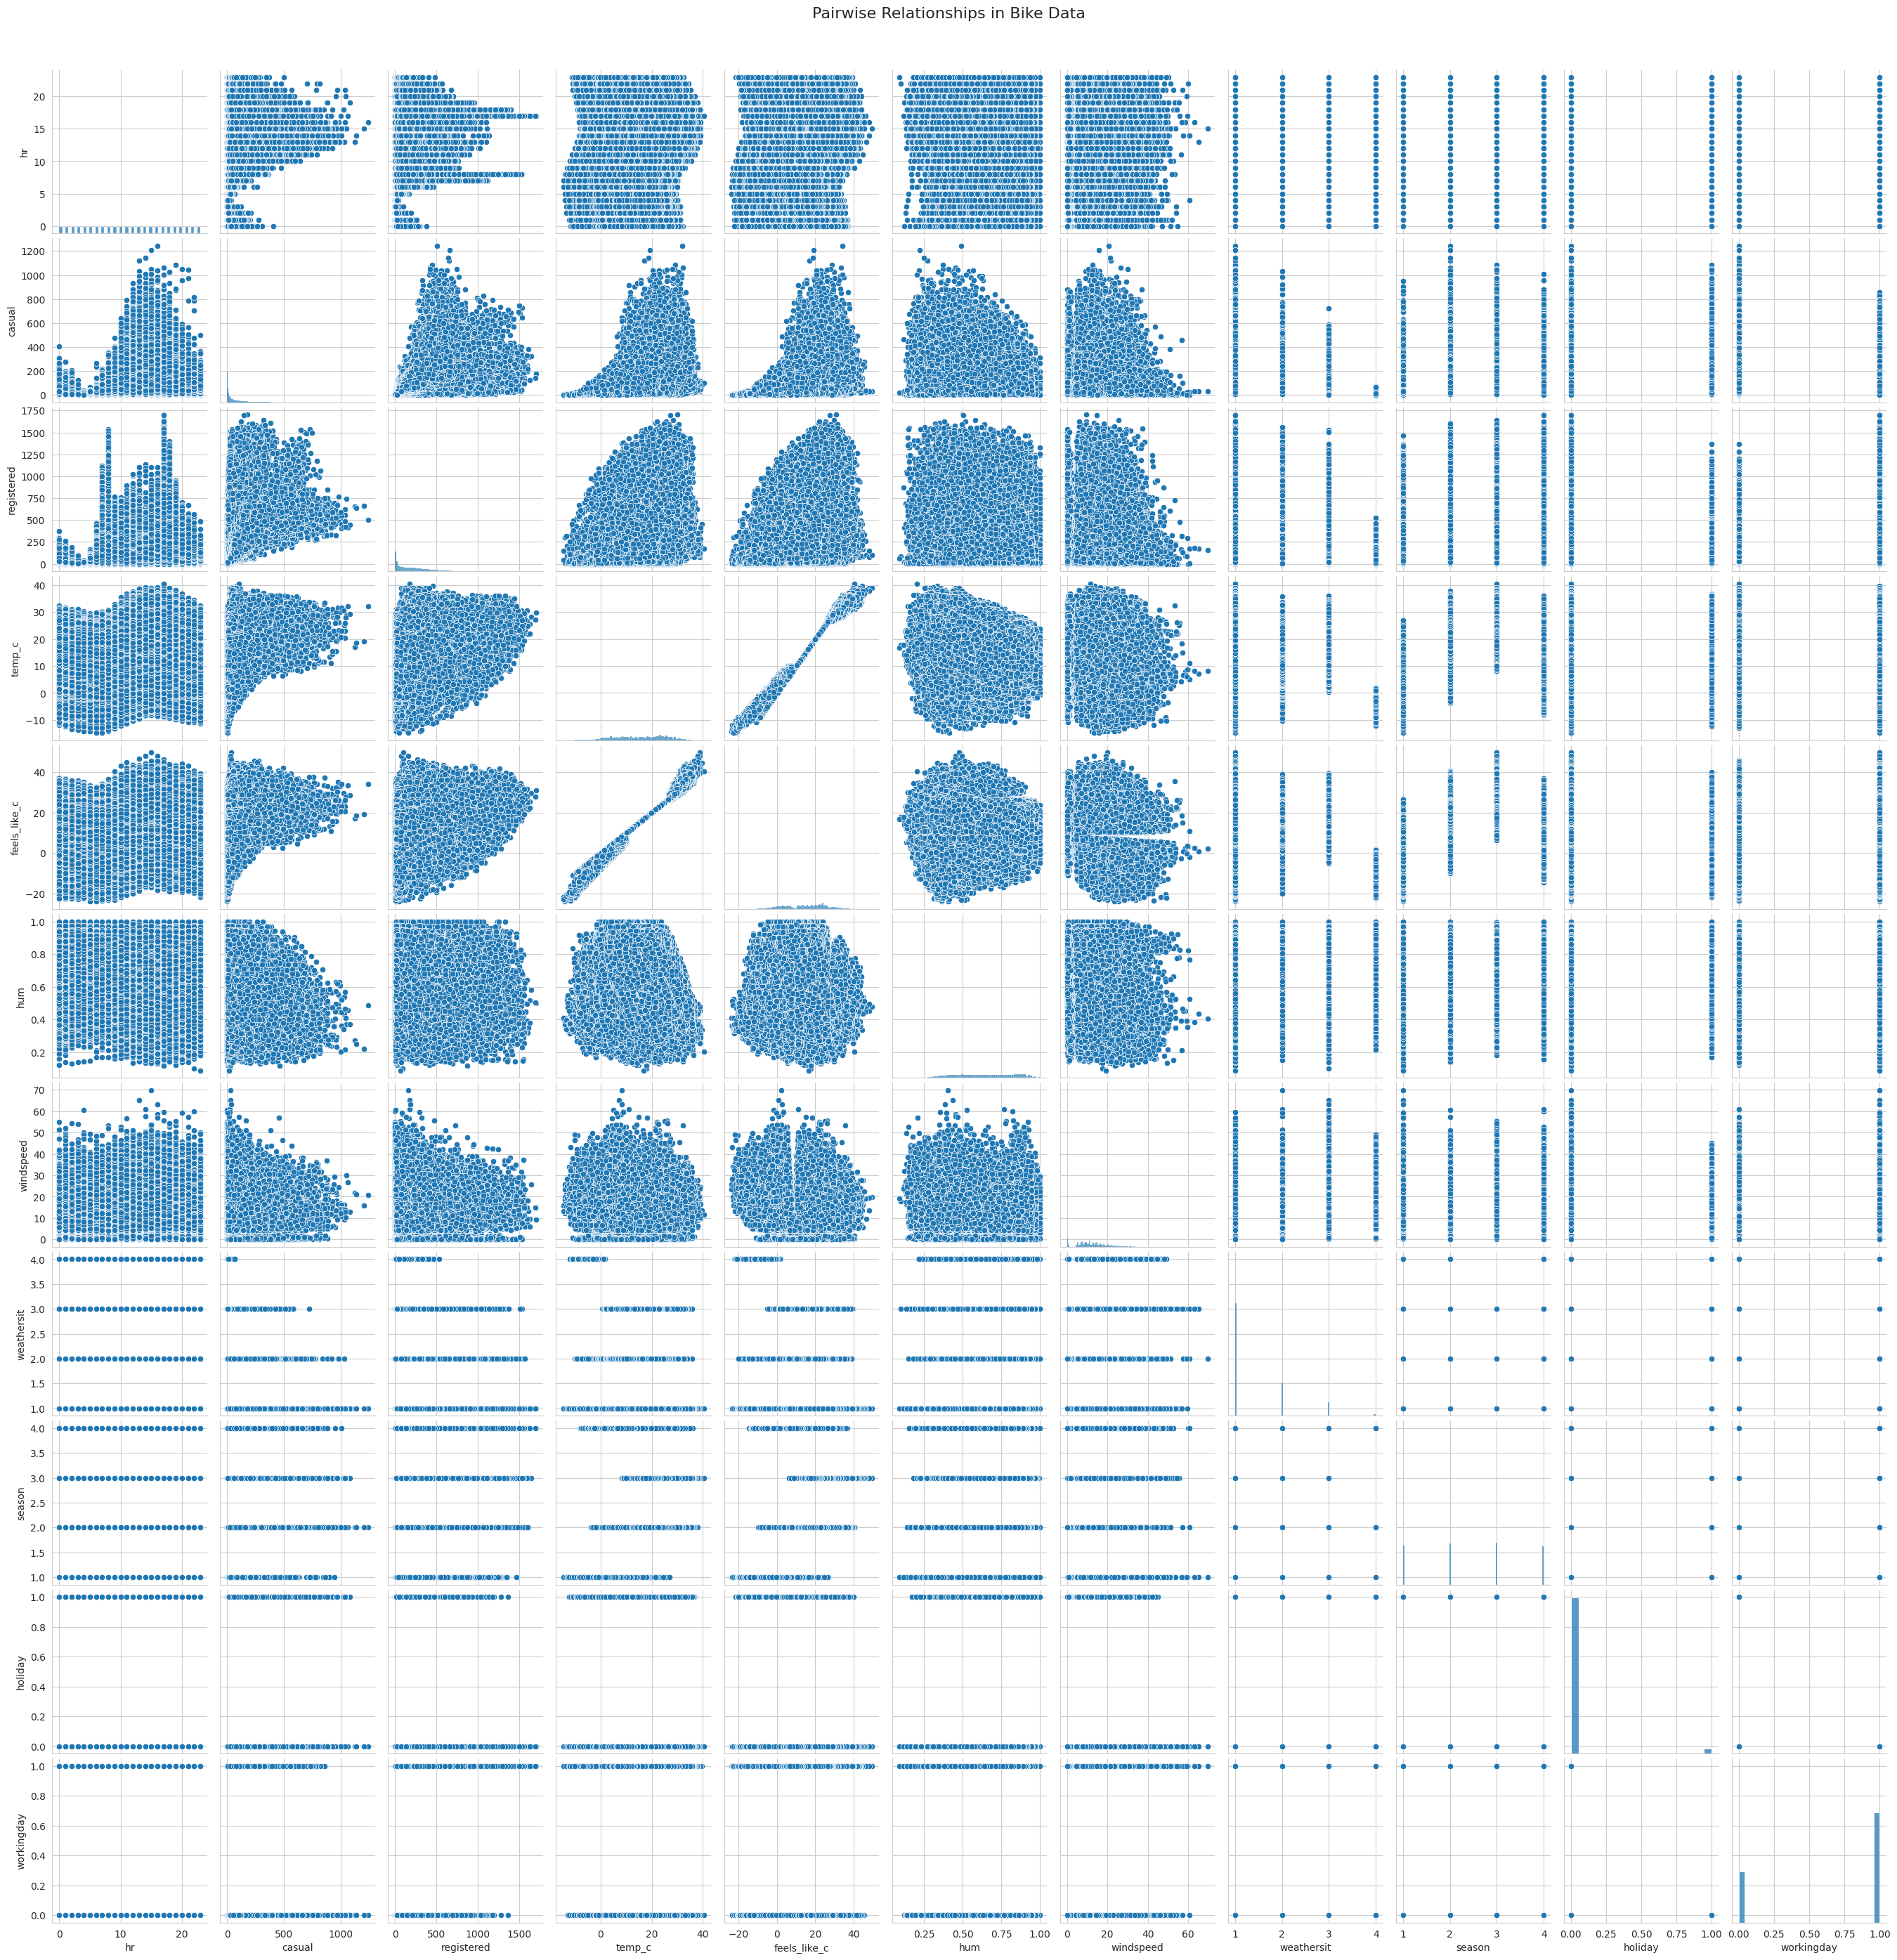

In [66]:
# Create the pairplot
sns.pairplot(bikes_pol.to_pandas())
plt.suptitle('Pairwise Relationships in Bike Data', y=1.02, fontsize=16)
plt.show()

In [68]:
# Sum 'casual' and 'registered' to create a 'count' column
bikes['count'] = bikes['casual'] + bikes['registered']

# Drop the original 'casual' and 'registered' columns
bikes = bikes.drop(columns = ['casual', 'registered'])

bikes

,dteday,hr,temp_c,feels_like_c,hum,windspeed,weathersit,season,holiday,workingday,count
0,1/1/2011,0.0,3.0,3.0,0.7957,0.8,1,1,0,0,16
1,1/1/2011,1.0,1.7,1.7,0.8272,0.8,1,1,0,0,38
2,1/1/2011,2.0,1.9,1.9,0.8157,1.1,1,1,0,0,31
3,1/1/2011,3.0,2.5,2.5,0.7831,0.8,1,1,0,0,12
4,1/1/2011,4.0,2.0,2.0,0.8075,1.1,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
112470,10/31/2023,19.0,10.2,10.2,0.4516,8.4,2,4,0,1,835
112471,10/31/2023,20.0,8.9,7.5,0.5268,9.3,1,4,0,1,621
112472,10/31/2023,21.0,7.7,6.4,0.5756,7.8,1,4,0,1,578
112473,10/31/2023,22.0,8.0,8.0,0.5604,0.0,1,4,0,1,363


In [69]:
# Sum 'casual' and 'registered' to create a 'count' column in bikes_pol
bikes_pol = bikes_pol.with_columns(
    (pl.col('casual') + pl.col('registered')).alias('count')
)

# Drop the original 'casual' and 'registered' columns
bikes_pol = bikes_pol.drop(['casual', 'registered'])

bikes_pol

dteday,hr,temp_c,feels_like_c,hum,windspeed,weathersit,season,holiday,workingday,count
str,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64
"""1/1/2011""",0.0,3.0,3.0,0.7957,0.8,1,1,0,0,16
"""1/1/2011""",1.0,1.7,1.7,0.8272,0.8,1,1,0,0,38
"""1/1/2011""",2.0,1.9,1.9,0.8157,1.1,1,1,0,0,31
"""1/1/2011""",3.0,2.5,2.5,0.7831,0.8,1,1,0,0,12
"""1/1/2011""",4.0,2.0,2.0,0.8075,1.1,1,1,0,0,1
…,…,…,…,…,…,…,…,…,…,…
"""10/31/2023""",19.0,10.2,10.2,0.4516,8.4,2,4,0,1,835
"""10/31/2023""",20.0,8.9,7.5,0.5268,9.3,1,4,0,1,621
"""10/31/2023""",21.0,7.7,6.4,0.5756,7.8,1,4,0,1,578


In [70]:
# Apply log1p transformation to the 'count' column in bikes and overwrite it
bikes['count'] = np.log1p(bikes['count'])

print(bikes['count'].describe())

count    112475.000000
mean          5.062013
std           1.541918
min           0.000000
25%           4.143135
50%           5.472271
75%           6.230481
max           7.724447
Name: count, dtype: float64


In [71]:
# Apply log1p transformation to the 'count' column in bikes_pol and overwrite it
bikes_pol = bikes_pol.with_columns(
    np.log1p(pl.col('count')).alias('count')
)

print(bikes_pol.select(pl.col('count')).describe())

shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ count    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 112475.0 │
│ null_count ┆ 0.0      │
│ mean       ┆ 5.062013 │
│ std        ┆ 1.541918 │
│ min        ┆ 0.0      │
│ 25%        ┆ 4.143135 │
│ 50%        ┆ 5.472271 │
│ 75%        ┆ 6.230481 │
│ max        ┆ 7.724447 │
└────────────┴──────────┘


In [72]:
# Convert 'dteday' to datetime objects
bikes['dteday'] = pd.to_datetime(bikes['dteday'])

# Extract day, month, and year
bikes['month'] = bikes['dteday'].dt.month
bikes['day'] = bikes['dteday'].dt.day
bikes['year'] = bikes['dteday'].dt.year

print(bikes[['dteday', 'month', 'day', 'year']])

# Drop the original 'dteday' column as its information has been extracted
bikes = bikes.drop('dteday', axis=1)
bikes

# Drop feels_like_c too? Not necessary, but not a bad idea either.

           dteday  month  day  year
0      2011-01-01      1    1  2011
1      2011-01-01      1    1  2011
2      2011-01-01      1    1  2011
3      2011-01-01      1    1  2011
4      2011-01-01      1    1  2011
...           ...    ...  ...   ...
112470 2023-10-31     10   31  2023
112471 2023-10-31     10   31  2023
112472 2023-10-31     10   31  2023
112473 2023-10-31     10   31  2023
112474 2023-10-31     10   31  2023

[112475 rows x 4 columns]


,hr,temp_c,feels_like_c,hum,windspeed,weathersit,season,holiday,workingday,count,month,day,year
0,0.0,3.0,3.0,0.7957,0.8,1,1,0,0,2.833213,1,1,2011
1,1.0,1.7,1.7,0.8272,0.8,1,1,0,0,3.663562,1,1,2011
2,2.0,1.9,1.9,0.8157,1.1,1,1,0,0,3.465736,1,1,2011
3,3.0,2.5,2.5,0.7831,0.8,1,1,0,0,2.564949,1,1,2011
4,4.0,2.0,2.0,0.8075,1.1,1,1,0,0,0.693147,1,1,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...
112470,19.0,10.2,10.2,0.4516,8.4,2,4,0,1,6.728629,10,31,2023
112471,20.0,8.9,7.5,0.5268,9.3,1,4,0,1,6.432940,10,31,2023
112472,21.0,7.7,6.4,0.5756,7.8,1,4,0,1,6.361302,10,31,2023
112473,22.0,8.0,8.0,0.5604,0.0,1,4,0,1,5.897154,10,31,2023


In [73]:
# Convert 'dteday' to datetime objects in bikes_pol
bikes_pol = bikes_pol.with_columns(
    pl.col('dteday').str.to_datetime('%m/%d/%Y').alias('dteday')
)

# Extract day, month, and year from the new datetime column
bikes_pol = bikes_pol.with_columns([
    pl.col('dteday').dt.month().alias('month'),
    pl.col('dteday').dt.day().alias('day'),
    pl.col('dteday').dt.year().alias('year')
])

print(bikes_pol.select(pl.col(['dteday', 'month', 'day', 'year'])))

# Drop the original 'dteday' (string) and the intermediate 'dteday_dt' columns
bikes_pol = bikes_pol.drop('dteday')

bikes_pol
# Drop feels_like_c too? Not necessary, but not a bad idea either.

shape: (112_475, 4)
┌─────────────────────┬───────┬─────┬──────┐
│ dteday              ┆ month ┆ day ┆ year │
│ ---                 ┆ ---   ┆ --- ┆ ---  │
│ datetime[μs]        ┆ i8    ┆ i8  ┆ i32  │
╞═════════════════════╪═══════╪═════╪══════╡
│ 2011-01-01 00:00:00 ┆ 1     ┆ 1   ┆ 2011 │
│ 2011-01-01 00:00:00 ┆ 1     ┆ 1   ┆ 2011 │
│ 2011-01-01 00:00:00 ┆ 1     ┆ 1   ┆ 2011 │
│ 2011-01-01 00:00:00 ┆ 1     ┆ 1   ┆ 2011 │
│ 2011-01-01 00:00:00 ┆ 1     ┆ 1   ┆ 2011 │
│ …                   ┆ …     ┆ …   ┆ …    │
│ 2023-10-31 00:00:00 ┆ 10    ┆ 31  ┆ 2023 │
│ 2023-10-31 00:00:00 ┆ 10    ┆ 31  ┆ 2023 │
│ 2023-10-31 00:00:00 ┆ 10    ┆ 31  ┆ 2023 │
│ 2023-10-31 00:00:00 ┆ 10    ┆ 31  ┆ 2023 │
│ 2023-10-31 00:00:00 ┆ 10    ┆ 31  ┆ 2023 │
└─────────────────────┴───────┴─────┴──────┘


hr,temp_c,feels_like_c,hum,windspeed,weathersit,season,holiday,workingday,count,month,day,year
f64,f64,f64,f64,f64,i64,i64,i64,i64,f64,i8,i8,i32
0.0,3.0,3.0,0.7957,0.8,1,1,0,0,2.833213,1,1,2011
1.0,1.7,1.7,0.8272,0.8,1,1,0,0,3.663562,1,1,2011
2.0,1.9,1.9,0.8157,1.1,1,1,0,0,3.465736,1,1,2011
3.0,2.5,2.5,0.7831,0.8,1,1,0,0,2.564949,1,1,2011
4.0,2.0,2.0,0.8075,1.1,1,1,0,0,0.693147,1,1,2011
…,…,…,…,…,…,…,…,…,…,…,…,…
19.0,10.2,10.2,0.4516,8.4,2,4,0,1,6.728629,10,31,2023
20.0,8.9,7.5,0.5268,9.3,1,4,0,1,6.43294,10,31,2023
21.0,7.7,6.4,0.5756,7.8,1,4,0,1,6.361302,10,31,2023


In [74]:
# Identify numerical columns for standardization
numeric_cols = [
    'hr', 'temp_c', 'feels_like_c', 'hum',
    'windspeed', 'month', 'day', 'year',
    'count'
]

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply standardization to the selected numerical columns
bikes[numeric_cols] = scaler.fit_transform(bikes[numeric_cols])

bikes[numeric_cols].describe()

,hr,temp_c,feels_like_c,hum,windspeed,month,day,year,count
count,1.124750e+05,1.124750e+05,1.124750e+05,1.124750e+05,1.124750e+05,1.124750e+05,1.124750e+05,1.124750e+05,1.124750e+05
mean,-1.023251e-16,-1.819394e-16,1.698101e-16,6.319866e-16,-1.541431e-16,3.032323e-18,4.876986e-17,2.817230e-14,-4.609131e-16
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-1.661568e+00,-3.084950e+00,-3.382779e+00,-2.877799e+00,-1.667261e+00,-1.594706e+00,-1.673758e+00,-1.599410e+00,-3.282947e+00
25%,-7.947458e-01,-7.976356e-01,-8.102121e-01,-8.013759e-01,-6.873139e-01,-1.010424e+00,-8.783078e-01,-7.890709e-01,-5.959348e-01
50%,7.207657e-02,6.395381e-02,1.173121e-01,2.246822e-02,-1.146175e-01,-1.340017e-01,3.077840e-02,2.126802e-02,2.660707e-01
75%,9.388990e-01,8.332301e-01,7.735793e-01,8.520919e-01,5.598917e-01,7.424208e-01,8.262288e-01,8.316069e-01,7.578050e-01
max,1.661251e+00,2.576923e+00,3.057389e+00,1.909218e+00,7.215897e+00,1.618843e+00,1.735315e+00,1.641946e+00,1.726710e+00


In [75]:
numeric_cols = [
    'hr', 'temp_c', 'feels_like_c', 'hum',
    'windspeed', 'month', 'day', 'year',
    'count'
]

bikes_pol_num = bikes_pol.select((pl.col(numeric_cols)-pl.col(numeric_cols).mean()) / pl.col(numeric_cols).std())

bikes_pol_num.describe()


statistic,hr,temp_c,feels_like_c,hum,windspeed,month,day,year,count
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",112475.0,112475.0,112475.0,112475.0,112475.0,112475.0,112475.0,112475.0,112475.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",-1.3772e-16,-5.5087e-17,-2.0317e-16,-4.5106e-16,-2.2692e-16,-4.1947e-17,4.2958e-17,2.8258e-14,-4.5030e-16
"""std""",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
"""min""",-1.661561,-3.084937,-3.382764,-2.877787,-1.667254,-1.594699,-1.673751,-1.599403,-3.282933
"""25%""",-0.794742,-0.797632,-0.810209,-0.801372,-0.687311,-1.01042,-0.878304,-0.789067,-0.595932
"""50%""",0.072076,0.063954,0.117312,0.022468,-0.114617,-0.134001,0.030778,0.021268,0.266069
"""75%""",0.938895,0.833226,0.773576,0.852088,0.559889,0.742417,0.826225,0.831603,0.757802
"""max""",1.661244,2.576911,3.057375,1.90921,7.215865,1.618836,1.735307,1.641939,1.726702


In [76]:
# Identify categorical columns to one-hot encode
category_cols = ['weathersit', 'season', 'holiday', 'workingday']

# Apply one-hot encoding using pd.get_dummies
bikes_encoded = pd.get_dummies(bikes, columns=category_cols, drop_first=True)

print("Original number of columns:", bikes.shape[1])
print("Number of columns after one-hot encoding:", bikes_encoded.shape[1])
bikes_encoded

Original number of columns: 13
Number of columns after one-hot encoding: 17


,hr,temp_c,feels_like_c,hum,windspeed,count,month,day,year,weathersit_2,weathersit_3,weathersit_4,season_2,season_3,season_4,holiday_1,workingday_1
0,-1.661568,-1.269458,-1.020218,0.835804,-1.565449,-1.445479,-1.594706,-1.673758,-1.599410,False,False,False,False,False,False,False,False
1,-1.517098,-1.402800,-1.133971,1.001309,-1.565449,-0.906960,-1.594706,-1.673758,-1.599410,False,False,False,False,False,False,False,False
2,-1.372627,-1.382286,-1.116470,0.940886,-1.527269,-1.035259,-1.594706,-1.673758,-1.599410,False,False,False,False,False,False,False,False
3,-1.228157,-1.320743,-1.063969,0.769602,-1.565449,-1.619460,-1.594706,-1.673758,-1.599410,False,False,False,False,False,False,False,False
4,-1.083687,-1.372029,-1.107720,0.897803,-1.527269,-2.833410,-1.594706,-1.673758,-1.599410,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112470,1.083369,-0.530953,-0.390201,-0.972134,-0.598228,1.080876,1.034562,1.735315,1.641946,True,False,False,False,False,True,False,True
112471,1.227840,-0.664294,-0.626457,-0.577026,-0.483689,0.889109,1.034562,1.735315,1.641946,False,False,False,False,False,True,False,True
112472,1.372310,-0.787379,-0.722710,-0.320625,-0.674587,0.842648,1.034562,1.735315,1.641946,False,False,False,False,False,True,False,True
112473,1.516781,-0.756608,-0.582706,-0.400487,-1.667261,0.541627,1.034562,1.735315,1.641946,False,False,False,False,False,True,False,True


In [77]:
# Identify categorical columns to one-hot encode
category_cols = ['weathersit', 'season', 'holiday', 'workingday']

# Apply one-hot encoding using pd.get_dummies
bikes_pol_cat = bikes_pol.select(categorical_cols).to_dummies(drop_first=True)

bikes_pol_cat

weathersit_2,weathersit_3,weathersit_4,season_2,season_3,season_4,holiday_1,workingday_1
u8,u8,u8,u8,u8,u8,u8,u8
0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…
1,0,0,0,0,1,0,1
0,0,0,0,0,1,0,1
0,0,0,0,0,1,0,1


In [78]:
# Column bind bikes_pol_num and bikes_pol_cat
bikes_pol_final = pl.concat([bikes_pol_num, bikes_pol_cat], how='horizontal')

bikes_pol_final

hr,temp_c,feels_like_c,hum,windspeed,month,day,year,count,weathersit_2,weathersit_3,weathersit_4,season_2,season_3,season_4,holiday_1,workingday_1
f64,f64,f64,f64,f64,f64,f64,f64,f64,u8,u8,u8,u8,u8,u8,u8,u8
-1.661561,-1.269453,-1.020213,0.8358,-1.565442,-1.594699,-1.673751,-1.599403,-1.445472,0,0,0,0,0,0,0,0
-1.517091,-1.402793,-1.133966,1.001304,-1.565442,-1.594699,-1.673751,-1.599403,-0.906956,0,0,0,0,0,0,0,0
-1.372621,-1.382279,-1.116465,0.940882,-1.527262,-1.594699,-1.673751,-1.599403,-1.035254,0,0,0,0,0,0,0,0
-1.228152,-1.320738,-1.063964,0.769599,-1.565442,-1.594699,-1.673751,-1.599403,-1.619453,0,0,0,0,0,0,0,0
-1.083682,-1.372022,-1.107715,0.897799,-1.527262,-1.594699,-1.673751,-1.599403,-2.833397,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1.083365,-0.530951,-0.390199,-0.97213,-0.598225,1.034557,1.735307,1.641939,1.080871,1,0,0,0,0,1,0,1
1.227834,-0.664291,-0.626455,-0.577023,-0.483686,1.034557,1.735307,1.641939,0.889105,0,0,0,0,0,1,0,1
1.372304,-0.787375,-0.722707,-0.320624,-0.674584,1.034557,1.735307,1.641939,0.842645,0,0,0,0,0,1,0,1
